In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, f1_score


In [112]:
df = pd.read_csv('flood_risk_dataset_modified.csv')
df.head()

,county,nearest_town,town_size,landcover_types,elevation_m,dist_to_town_m,dist_to_water_m,topographic_hazard,landcover_risk,water_proximity_risk,vulnerability_score,flood_risk_score,risk_category
0,Migori,Mohoni,Town,waterbodies,1134.0,14191.648756,9.891734e+06,0.0,9.0,0,0.0,2.2,Very High Risk
1,Migori,Mohoni,Town,waterbodies,1134.0,16419.789667,9.898062e+06,0.0,9.0,0,0.0,2.2,Very High Risk
2,Migori,Nyatembe,Town,waterbodies,1134.0,18365.752928,9.904390e+06,0.0,9.0,0,0.0,2.2,Very High Risk
3,Migori,Nyandhiwa,Town,waterbodies,1134.0,13839.292053,9.910718e+06,0.0,9.0,0,0.0,2.2,Very High Risk
4,Homa Bay,Nyandhiwa,Town,waterbodies,1134.0,10562.446388,9.917045e+06,0.0,9.0,0,0.0,2.2,Very High Risk


In [113]:
# drop highly correlated features
df.drop([ 'flood_risk_score','landcover_risk','landcover_types'], axis=1, inplace=True)

In [114]:
# preprocessing

# label encoding for categorical variables
label_encoder = LabelEncoder()
df['county'] = label_encoder.fit_transform(df['county'])
df['nearest_town'] = label_encoder.fit_transform(df['nearest_town'])
df['town_size'] = label_encoder.fit_transform(df['town_size'])
#df['landcover_types'] = label_encoder.fit_transform(df['landcover_types'])
df['risk_category'] = label_encoder.fit_transform(df['risk_category'])

In [115]:
# train-test split
X = df.drop('risk_category', axis=1)
y = df['risk_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [116]:
# call random forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)



In [117]:
# cross validation score
cv_scores_rf = cross_val_score(rf_classifier, X_train, y_train, cv=5)
print("Random Forest Classifier Cross-Validation Scores:", cv_scores_rf)
print("Random Forest Classifier Average CV Score:", np.mean(cv_scores_rf))


Random Forest Classifier Cross-Validation Scores: [0.77844828 0.78534483 0.79517033 0.78654592 0.79560155]
Random Forest Classifier Average CV Score: 0.7882221825697758


In [118]:
# evaluate the random forest classifier

print("Random Forest Classifier Evaluation:")

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_rf, average='weighted') * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))





Random Forest Classifier Evaluation:
Accuracy: 79.66%
F1 Score: 79.64%

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.67      0.70       747
           1       0.74      0.79      0.76       623
           2       0.71      0.78      0.74       281
           3       0.89      0.88      0.89      1249

    accuracy                           0.80      2900
   macro avg       0.77      0.78      0.77      2900
weighted avg       0.80      0.80      0.80      2900



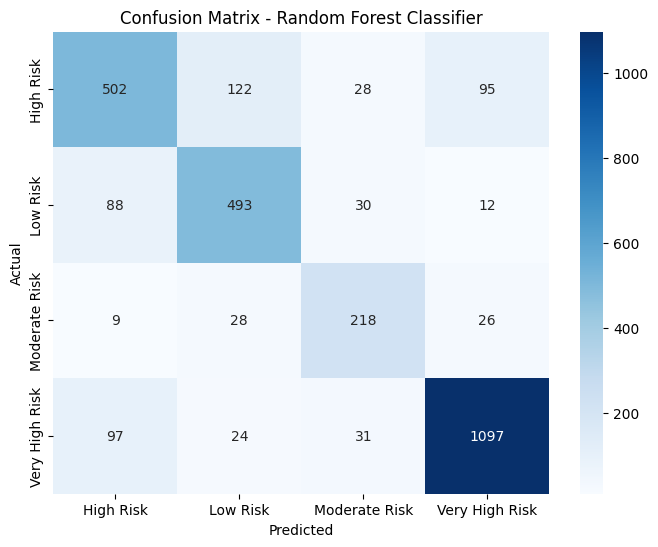

In [119]:
# plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()

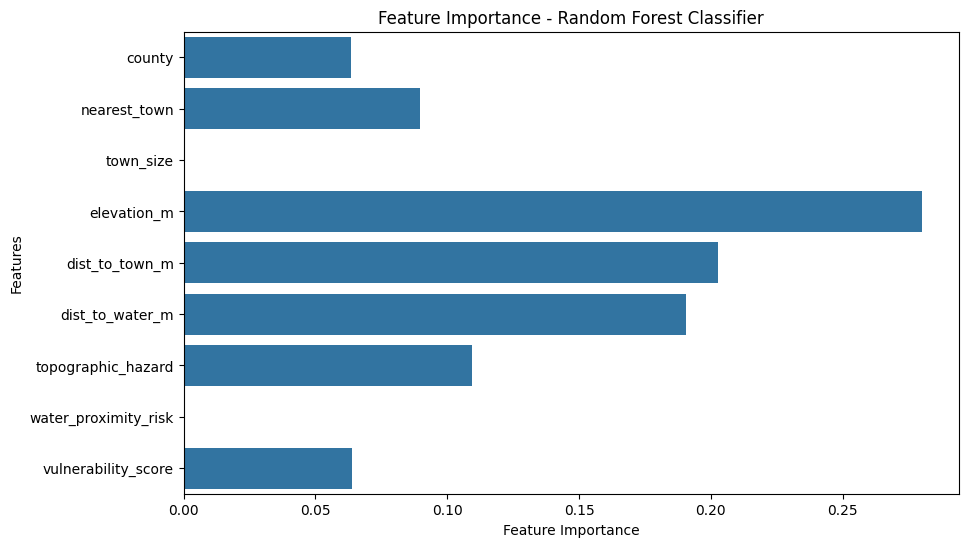

In [120]:
# plot feature importance
feature_importances = rf_classifier.feature_importances_
features = X.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=features)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Random Forest Classifier')
plt.show()

In [121]:
# call xgboost classifier
xgb_classifier = XGBClassifier(n_estimators=100, random_state=42)
xgb_classifier.fit(X_train, y_train)
y_pred_xgb = xgb_classifier.predict(X_test)


In [122]:
# evaluation metrics for xgboost 
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("XGBoost Classifier Evaluation:")

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb, average='weighted') * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


XGBoost Classifier Evaluation:
Accuracy: 80.10%
F1 Score: 80.11%

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.69      0.71       747
           1       0.73      0.80      0.76       623
           2       0.71      0.73      0.72       281
           3       0.90      0.88      0.89      1249

    accuracy                           0.80      2900
   macro avg       0.77      0.78      0.77      2900
weighted avg       0.80      0.80      0.80      2900



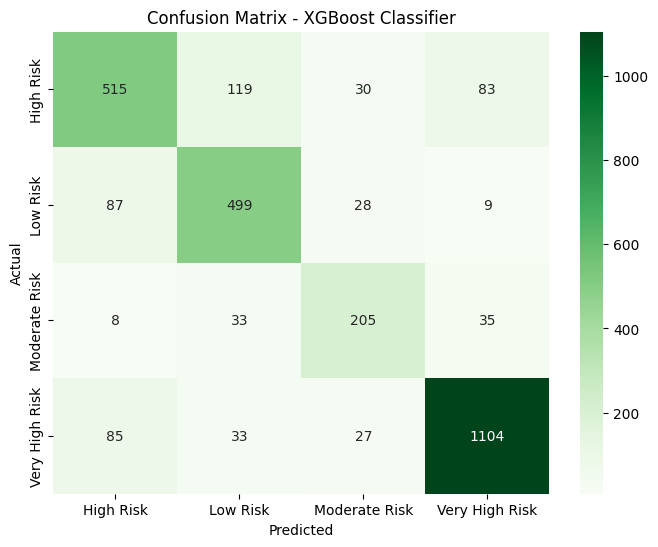

In [123]:
# confusion matrix for xgboost
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Greens', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost Classifier')
plt.show()

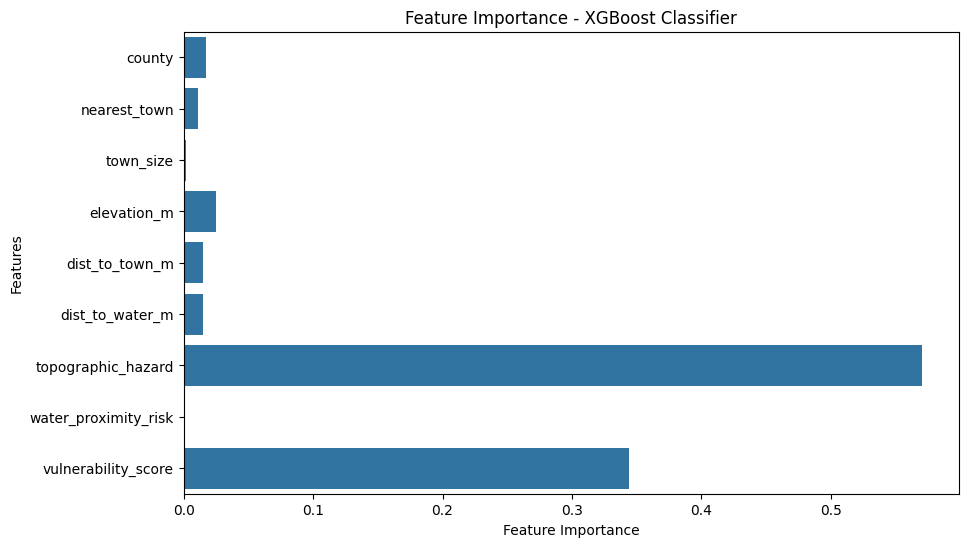

In [124]:
# xgboost feature importance
xgb_feature_importances = xgb_classifier.feature_importances_
xgb_features = X.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_feature_importances, y=xgb_features)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance - XGBoost Classifier')
plt.show()